In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [46]:
import kagglehub
path = kagglehub.dataset_download("uciml/iris")

Using Colab cache for faster access to the 'iris' dataset.


In [47]:
df = pd.read_csv(path + '/Iris.csv', usecols=['SepalLengthCm','PetalLengthCm','Species'])
df

,SepalLengthCm,PetalLengthCm,Species
0,5.1,1.4,Iris-setosa
1,4.9,1.4,Iris-setosa
2,4.7,1.3,Iris-setosa
3,4.6,1.5,Iris-setosa
4,5.0,1.4,Iris-setosa
...,...,...,...
145,6.7,5.2,Iris-virginica
146,6.3,5.0,Iris-virginica
147,6.5,5.2,Iris-virginica
148,6.2,5.4,Iris-virginica


In [48]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

In [49]:
X = df.drop('Species', axis=1)
y = df['Species']

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(multi_class='multinomial')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

1.0

In [53]:
from sklearn.metrics import confusion_matrix
pd.DataFrame(confusion_matrix(y_test, y_pred))

,0,1,2
0,10,0,0
1,0,9,0
2,0,0,11


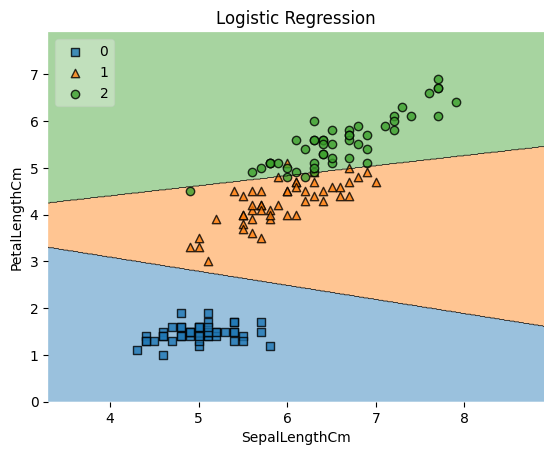

In [54]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values, y.values, clf=model, legend=2)
plt.xlabel('SepalLengthCm')
plt.ylabel('PetalLengthCm')
plt.title('Logistic Regression')
plt.show()

In [55]:
# Prediction
query = np.array([[7.4,2.7]])
model.predict_proba(query)

array([[1.65718317e-01, 8.34169192e-01, 1.12490530e-04]])

In [56]:
model.predict(query)

array([1])

# Polynomial Features Logistic regression

In [57]:
import kagglehub
path = kagglehub.dataset_download("darshakofficial/ushape1")

Using Colab cache for faster access to the 'ushape1' dataset.


In [58]:
df = pd.read_csv(path + '/ushape.csv')
df

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0
...,...,...,...
94,1.699453,0.587720,1.0
95,0.218623,-0.652521,1.0
96,0.952914,-0.419766,1.0
97,-1.318500,0.423112,0.0


In [59]:
df.columns = ['Feature1', 'Feature2', 'Target']
df

,Feature1,Feature2,Target
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0
...,...,...,...
94,1.699453,0.587720,1.0
95,0.218623,-0.652521,1.0
96,0.952914,-0.419766,1.0
97,-1.318500,0.423112,0.0


In [60]:
X = df.drop('Target', axis=1)
y = df['Target']

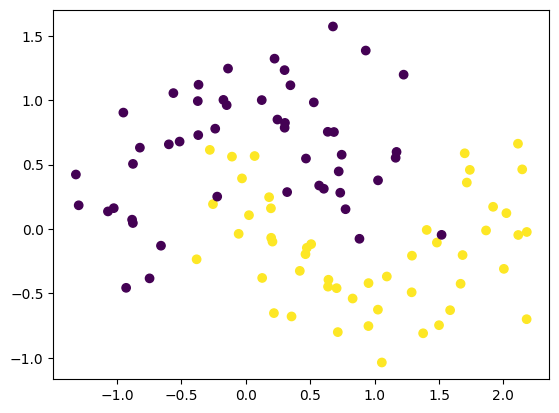

In [61]:
plt.scatter(X['Feature1'], X['Feature2'], c=y)

In [62]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

<Axes: >

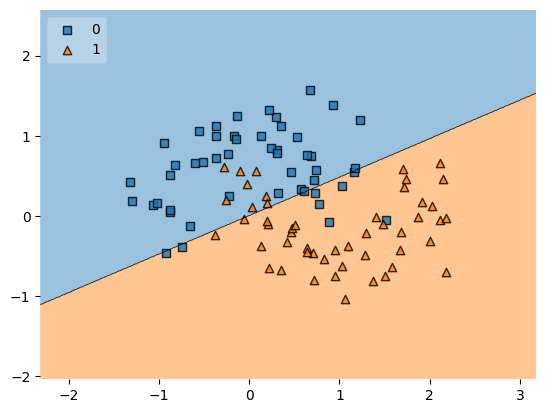

In [63]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values, y.astype('int').values, clf=model, legend=2)

In [80]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(model, X, y, scoring='accuracy', cv=10)).round(2)

np.float64(0.83)

In [81]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

In [82]:
model1 = LogisticRegression()
model1.fit(X_poly, y)
np.mean(cross_val_score(model1, X_poly, y, scoring='accuracy', cv=10)).round(2)

np.float64(0.83)

In [85]:
def plot_decision_boundary(X,y,degree=1):

    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)

    clf = LogisticRegression()
    clf.fit(X_trf,y)

    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))

    # Convert X to a NumPy array to allow for array-style slicing
    X_np = X.values if isinstance(X, pd.DataFrame) else X

    a=np.arange(start=X_np[:,0].min()-1, stop=X_np[:,0].max()+1, step=0.01)
    b=np.arange(start=X_np[:,1].min()-1, stop=X_np[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)

    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))

    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X_np[:,0],X_np[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

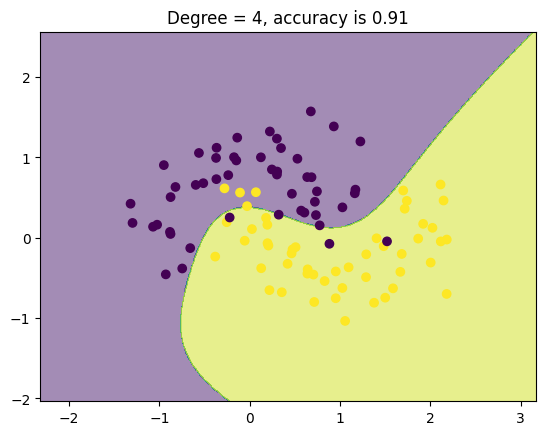

In [98]:
plot_decision_boundary(X,y,degree=4)